<span style="float: left;padding: 1.3em">![logo](https://github.com/Hazem-74/LIGO-GW-Workshop/blob/main/Ligo.png?raw=1)</span>
<span style="float: right;padding: 1.3em">![logo](https://github.com/Hazem-74/LIGO-GW-Workshop/blob/main/Zewail-City.png?raw=1)</span>

---
# Challenge #4 (_Advanced_)

In [1]:
!pip install bilby matplotlib numpy pycbc

In [2]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

In [3]:
# Main Libraries
from pycbc.frame import read_frame
from pycbc.filter import highpass, matched_filter, resample_to_delta_t
from pycbc.psd import welch, interpolate
from pycbc.types import FrequencySeries
from pycbc.waveform import get_td_waveform
from pycbc.vetoes import power_chisq
import matplotlib.pyplot as plt
from pycbc.events.ranking import newsnr
import numpy as np
import gc
import bilby
from bilby.gw.conversion import convert_to_lal_binary_black_hole_parameters

### Use the data file challenge3.gwf with channels H1:CHALLENGE3 and L1:CHALLENGE3.
### These are real LIGO data from O2, though we've adjusted the time labels and added some simulated signals.
### Any simulated signals have been added to both the H1 and L1 data
### All simulated signals have spin = 0 and m1 = m2, with m1 somewhere in the range 10-50 solar masses

In [4]:
# Load both H1 and L1 data
file_name = "/content/challenge3.gwf"
h1_channel = "H1:CHALLENGE3"
l1_channel = "L1:CHALLENGE3"

h1_data = read_frame(file_name, h1_channel)
l1_data = read_frame(file_name, l1_channel)

#f = FrameFile(file_name)
#h1_data = f.get_channel("H1:CHALLENGE3")
#l1_data = f.get_channel("L1:CHALLENGE3")

print("H1:", h1_data.sample_rate, "Hz,", h1_data.duration, "s")
print("L1:", l1_data.sample_rate, "Hz,", l1_data.duration, "s")

H1: 4096.0 Hz, 4096.0 s
L1: 4096.0 Hz, 4096.0 s


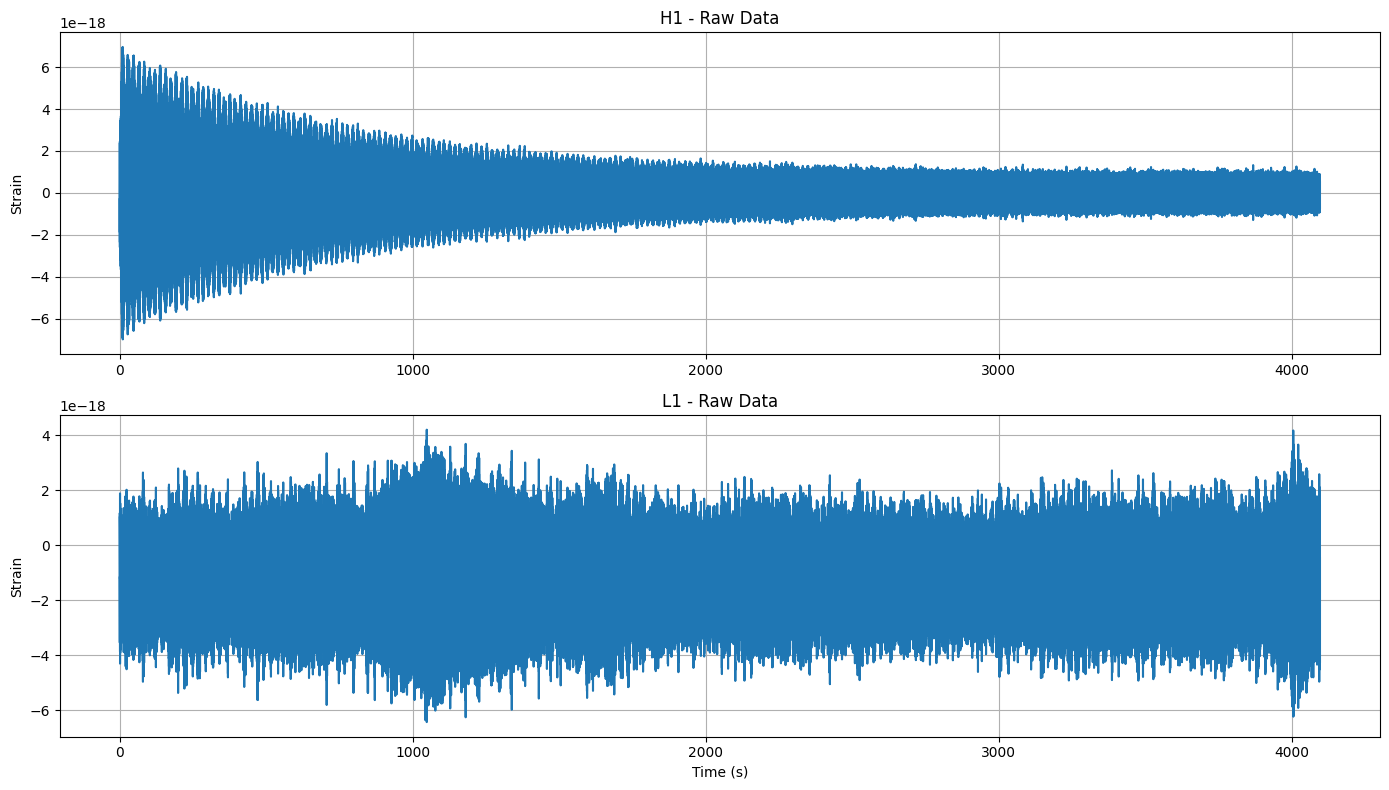

In [5]:
# Plot both detectors' raw data
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(h1_data.sample_times, h1_data)
axes[0].set_ylabel("Strain")
axes[0].set_title("H1 - Raw Data")
axes[0].grid()

axes[1].plot(l1_data.sample_times, l1_data)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Strain")
axes[1].set_title("L1 - Raw Data")
axes[1].grid()

plt.tight_layout()
plt.show()

In [6]:
# Apply highpass filter and crop edges
def filter_and_crop_data(data, f_low=30.0, crop_dur=720):
    """Filter and crop data following Challenge #3 method"""
    # Highpass filter
    data_hp = highpass(data, f_low)

    # Crop the edges to remove filter artifacts
    crop_samples = int(crop_dur * data.sample_rate)
    data_filtered = data_hp[crop_samples:-crop_samples]

    return data_filtered

h1_filtered = filter_and_crop_data(h1_data)
l1_filtered = filter_and_crop_data(l1_data)

print(f"H1 - Original duration: {h1_data.duration:.1f} s, Filtered: {h1_filtered.duration:.1f} s")
print(f"L1 - Original duration: {l1_data.duration:.1f} s, Filtered: {l1_filtered.duration:.1f} s")
print(f"Cropped: 720 s from each end")

H1 - Original duration: 4096.0 s, Filtered: 2656.0 s
L1 - Original duration: 4096.0 s, Filtered: 2656.0 s
Cropped: 720 s from each end


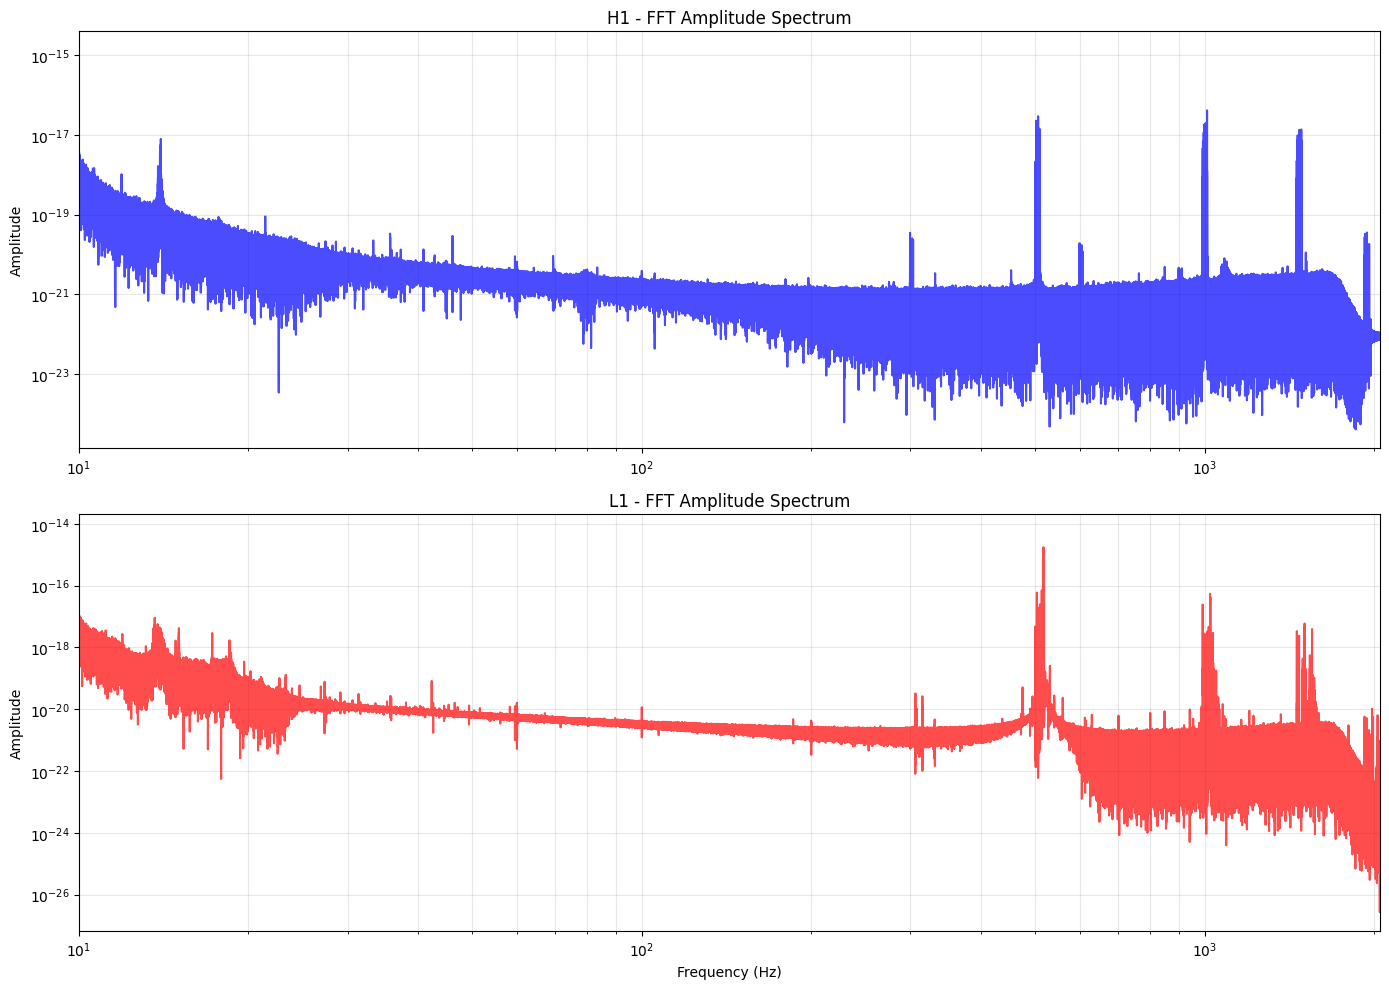

In [7]:
# Compute and plot FFT for both detectors

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# H1 FFT
h1_fft = h1_data.to_frequencyseries()
axes[0].loglog(h1_fft.sample_frequencies, abs(h1_fft), alpha=0.7, color='blue')
axes[0].set_ylabel("Amplitude")
axes[0].set_title("H1 - FFT Amplitude Spectrum")
axes[0].set_xlim(10, h1_data.sample_rate/2)
axes[0].grid(which='both', alpha=0.3)

# L1 FFT
l1_fft = l1_data.to_frequencyseries()
axes[1].loglog(l1_fft.sample_frequencies, abs(l1_fft), alpha=0.7, color='red')
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Amplitude")
axes[1].set_title("L1 - FFT Amplitude Spectrum")
axes[1].set_xlim(10, l1_data.sample_rate/2)
axes[1].grid(which='both', alpha=0.3)

plt.tight_layout()
plt.show()

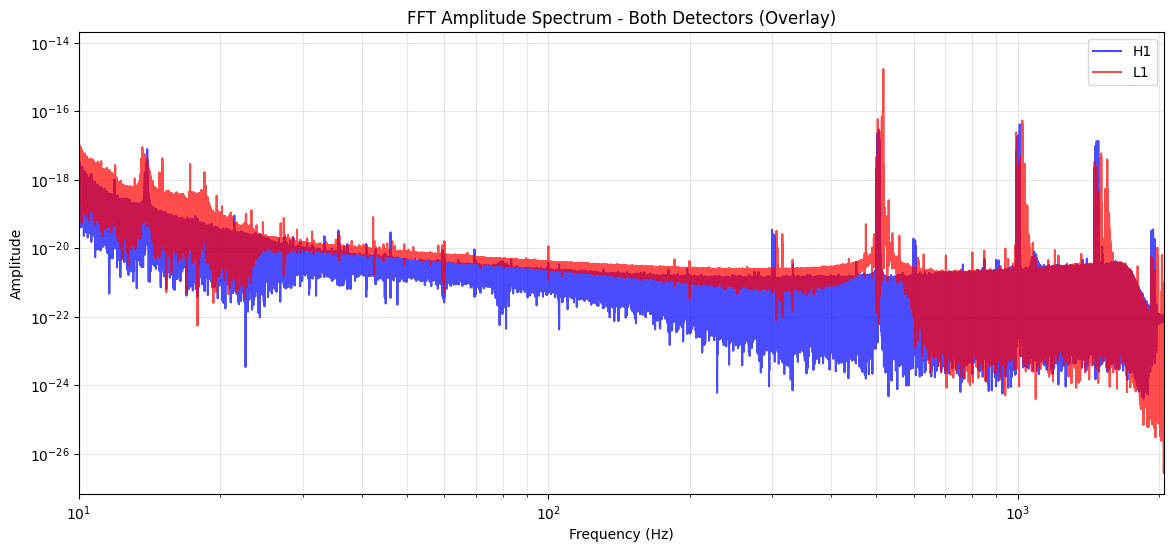

In [8]:
# Overlay comparison
plt.figure(figsize=(14, 6))
plt.loglog(h1_fft.sample_frequencies, abs(h1_fft), alpha=0.7, label='H1', color='blue')
plt.loglog(l1_fft.sample_frequencies, abs(l1_fft), alpha=0.7, label='L1', color='red')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("FFT Amplitude Spectrum - Both Detectors (Overlay)")
plt.xlim(10, h1_data.sample_rate/2)
plt.legend()
plt.legend(loc='upper right')  # Specify location explicitly
plt.grid(which='both', alpha=0.3)
plt.show()

In [1]:
# Q-transform visualization for both detectors
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# H1 Q-transform
h1_times, h1_freqs, h1_qpower = h1_filtered.qtransform(
    delta_t=0.001,
    logfsteps=200,
    qrange=(4, 64),
    frange=(20, 512)
)
axes[0].pcolormesh(h1_times, h1_freqs, h1_qpower**0.5,
                   cmap='viridis', shading='auto')
axes[0].set_yscale('log')
axes[0].set_ylabel('Frequency (Hz)')
axes[0].set_title('H1 - Q-transform')
axes[0].set_ylim(20, 512)

# L1 Q-transform
l1_times, l1_freqs, l1_qpower = l1_filtered.qtransform(
    delta_t=0.001,
    logfsteps=200,
    qrange=(4, 64),
    frange=(20, 512)
)
axes[1].pcolormesh(l1_times, l1_freqs, l1_qpower**0.5,
                   cmap='viridis', shading='auto')
axes[1].set_yscale('log')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Frequency (Hz)')
axes[1].set_title('L1 - Q-transform')
axes[1].set_ylim(20, 512)

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

In [ ]:
# Calculate PSDs for both detectors
h1_psd = welch(h1_filtered, seg_len=int(8*h1_filtered.sample_rate),
               seg_stride=int(4*h1_filtered.sample_rate))
l1_psd = welch(l1_filtered, seg_len=int(8*l1_filtered.sample_rate),
               seg_stride=int(4*l1_filtered.sample_rate))

In [ ]:
# Plot PSDs
plt.figure(figsize=(12, 6))
plt.loglog(h1_psd.sample_frequencies, h1_psd, label='H1', alpha=0.7)
plt.loglog(l1_psd.sample_frequencies, l1_psd, label='L1', alpha=0.7)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (1/Hz)")
plt.title("Power Spectral Density - Both Detectors")
plt.xlim(20, h1_filtered.sample_rate/2)
plt.legend()
plt.grid(which='both', alpha=0.3)
plt.show()

In [ ]:
# Function to search for signals with different masses
def search_for_signal(data, psd, mass, f_low=30.0,
                      snr_crop_dur=4, chisq_bins=16):
    """ Generate template and calculate SNR for given mass"""
    # Generate waveform
    hp, _ = get_td_waveform(
        approximant='SEOBNRv4_opt',
        mass1=mass,
        mass2=mass,
        spin1z=0,
        spin2z=0,
        delta_t=1.0 / data.sample_rate,
        f_lower=f_low
    )

    hp.resize(len(data))
    psd_interp = interpolate(psd, hp.delta_f)

    # Matched filter
    snr = matched_filter(hp, data,
                         psd=psd_interp,
                         low_frequency_cutoff=f_low)

    # χ² test
    chisq = power_chisq(
        hp, data,
        num_bins=chisq_bins,
        psd=psd_interp,
        low_frequency_cutoff=f_low
    )

    # Reduced χ²
    dof = 2 * chisq_bins - 2
    chisq_r = chisq / dof

    # Reweighted SNR
    snr_new = newsnr(abs(snr), chisq_r)

    # Crop edges
    crop = int(snr_crop_dur * snr.sample_rate)
    snr = snr[crop:-crop]
    chisq_r = chisq_r[crop:-crop]
    snr_new = snr_new[crop:-crop]

    # Extract and crop time array
    time_array = snr.sample_times

    return snr, hp, chisq_r, snr_new, time_array

In [ ]:
# coincident
def coincident(time_h1, time_l1, window=0.01):
    return abs(time_h1 - time_l1) <= window

In [ ]:
# plot function with 4 subplots (2 per detector)
def plot_snr_both_detectors(snr_h1, times_h1, snr_l1, times_l1, mass, zoom_window=0.2):
    """
    Plot SNR time series for both detectors with 4 subplots:
    - H1 full time series
    - H1 zoomed around peak
    - L1 full time series
    - L1 zoomed around peak
    """

    snr_h1_abs = np.abs(snr_h1)
    snr_l1_abs = np.abs(snr_l1)

    peak_idx_h1 = np.argmax(snr_h1_abs)
    peak_snr_h1 = snr_h1_abs[peak_idx_h1]
    peak_time_h1 = times_h1[peak_idx_h1]

    peak_idx_l1 = np.argmax(snr_l1_abs)
    peak_snr_l1 = snr_l1_abs[peak_idx_l1]
    peak_time_l1 = times_l1[peak_idx_l1]

    fig, axs = plt.subplots(2, 2, figsize=(16, 10))

    # H1 - Full time series
    axs[0, 0].plot(times_h1, snr_h1_abs, lw=1, color='blue', alpha=0.7)
    axs[0, 0].axhline(y=8, color='gray', linestyle='--', alpha=0.5, label='Threshold')
    axs[0, 0].set_xlabel("Time (s)")
    axs[0, 0].set_ylabel("SNR")
    axs[0, 0].set_title(f"H1 - Full SNR Time Series (m1=m2={mass} M☉)")
    axs[0, 0].legend(loc='upper right')
    axs[0, 0].grid()

    # H1 - Zoomed around peak
    axs[0, 1].plot(times_h1, snr_h1_abs, lw=2, color='blue', alpha=0.8)
    axs[0, 1].axhline(y=8, color='gray', linestyle='--', alpha=0.5)
    axs[0, 1].set_xlim(peak_time_h1 - zoom_window, peak_time_h1 + zoom_window)
    axs[0, 1].set_xlabel("Time (s)")
    axs[0, 1].set_ylabel("SNR")
    axs[0, 1].set_title(f"H1 - Zoomed (±{zoom_window}s around peak)")
    axs[0, 1].legend(loc='upper right')
    axs[0, 1].grid()

    # L1 - Full time series
    axs[1, 0].plot(times_l1, snr_l1_abs, lw=1, color='red', alpha=0.7)
    axs[1, 0].axhline(y=8, color='gray', linestyle='--', alpha=0.5, label='Threshold')
    axs[1, 0].set_xlabel("Time (s)")
    axs[1, 0].set_ylabel("SNR")
    axs[1, 0].set_title(f"L1 - Full SNR Time Series (m1=m2={mass} M☉)")
    axs[1, 0].legend(loc='upper right')
    axs[1, 0].grid()

    # L1 - Zoomed around peak
    axs[1, 1].plot(times_l1, snr_l1_abs, lw=2, color='red', alpha=0.8)
    axs[1, 1].axhline(y=8, color='gray', linestyle='--', alpha=0.5)
    axs[1, 1].set_xlim(peak_time_l1 - zoom_window, peak_time_l1 + zoom_window)
    axs[1, 1].set_xlabel("Time (s)")
    axs[1, 1].set_ylabel("SNR")
    axs[1, 1].set_title(f"L1 - Zoomed (±{zoom_window}s around peak)")
    axs[1, 1].legend(loc='upper right')
    axs[1, 1].grid()

    plt.tight_layout()
    plt.show()

    return peak_time_h1, peak_snr_h1, peak_time_l1, peak_snr_l1

In [ ]:
# Search over mass range: 10 to 50 solar masses
masses_to_search = [10, 15, 20, 25, 30, 35, 40, 45, 50]

### Identify as many signals as you can. Watch out! These are real data, and so glitches may be present. For each signal you find, list:
- The merger time
- The SNR
- estimate of the component masses

In [ ]:
# Storing data
h1_results = {}
l1_results = {}

# Storage for full SNR time series and templates
h1_snr_timeseries = {}
l1_snr_timeseries = {}
h1_templates = {}
l1_templates = {}
h1_chisq_timeseries = {}
l1_chisq_timeseries = {}

# Thresholds
snr_threshold = 8.0
chisq_threshold = 2.0

In [ ]:
# Loop
for mass in masses_to_search:
    print(f"MASS: {mass} + {mass} M☉")
    f_lower = max(20, 30 * (10 / mass))

    # Process H1
    snr_h1, template_h1, chisq_r_h1, snr_new_h1, times_h1 = search_for_signal(
        h1_filtered, h1_psd, mass, f_low=f_lower
    )
    snr_abs_h1 = np.abs(snr_new_h1)
    peak_idx_h1 = np.argmax(snr_abs_h1)
    peak_snr_h1 = snr_abs_h1[peak_idx_h1]
    peak_time_h1 = times_h1[peak_idx_h1]
    peak_chisq_h1 = chisq_r_h1[peak_idx_h1]

    # Process L1
    snr_l1, template_l1, chisq_r_l1, snr_new_l1, times_l1 = search_for_signal(
        l1_filtered, l1_psd, mass, f_low=f_lower
    )
    snr_abs_l1 = np.abs(snr_new_l1)
    peak_idx_l1 = np.argmax(snr_abs_l1)
    peak_snr_l1 = snr_abs_l1[peak_idx_l1]
    peak_time_l1 = times_l1[peak_idx_l1]
    peak_chisq_l1 = chisq_r_l1[peak_idx_l1]

    # Store all data for further investigations
    h1_results[mass] = {
        "peak_time": peak_time_h1,
        "peak_snr": peak_snr_h1,
        "chisq_r": peak_chisq_h1,
        "peak_idx": peak_idx_h1
    }

    l1_results[mass] = {
        "peak_time": peak_time_l1,
        "peak_snr": peak_snr_l1,
        "chisq_r": peak_chisq_l1,
        "peak_idx": peak_idx_l1
    }

    # Store full time series data
    h1_snr_timeseries[mass] = {
        "snr": snr_new_h1,
        "times": times_h1,
        "snr_abs": snr_abs_h1
    }

    l1_snr_timeseries[mass] = {
        "snr": snr_new_l1,
        "times": times_l1,
        "snr_abs": snr_abs_l1
    }

    # Store templates and chi-squared
    h1_templates[mass] = template_h1
    l1_templates[mass] = template_l1
    h1_chisq_timeseries[mass] = chisq_r_h1
    l1_chisq_timeseries[mass] = chisq_r_l1

    # Plot both detectors
    plot_snr_both_detectors(snr_new_h1, times_h1, snr_new_l1, times_l1, mass, zoom_window=0.2)

    # Print basic results
    print(f"\n┌─ H1 Results ────────────────────────────────────────────────┐")
    print(f"│ SNR: {peak_snr_h1:6.2f}  |  χ²ᵣ: {peak_chisq_h1:5.2f}  |  Time: {peak_time_h1:8.2f} s │")
    print(f"└───────────────────────────────────────────────────────────────┘")

    print(f"┌─ L1 Results ──────────────────────────────────────────────────┐")
    print(f"│ SNR: {peak_snr_l1:6.2f}  |  χ²ᵣ: {peak_chisq_l1:5.2f}  |  Time: {peak_time_l1:8.2f} s │")
    print(f"└───────────────────────────────────────────────────────────────┘")

In [ ]:
# Coincidence analysis
coincidence_results = {}

for mass in masses_to_search:
    peak_time_h1 = h1_results[mass]["peak_time"]
    peak_time_l1 = l1_results[mass]["peak_time"]
    peak_snr_h1 = h1_results[mass]["peak_snr"]
    peak_snr_l1 = l1_results[mass]["peak_snr"]

    time_diff = abs(peak_time_h1 - peak_time_l1)
    is_coincident = time_diff <= 0.01  # 10ms window

    coincidence_results[mass] = {
        "time_difference": time_diff,
        "is_coincident": is_coincident,
        "h1_peak_time": peak_time_h1,
        "l1_peak_time": peak_time_l1,
        "h1_snr": peak_snr_h1,
        "l1_snr": peak_snr_l1
    }

    print(f"\nMass {mass}+{mass} M☉:")
    if is_coincident:
        print(f"   COINCIDENT: Δt = {time_diff*1000:.2f} ms")
    else:
        print(f"   NOT COINCIDENT: Δt = {time_diff*1000:.2f} ms")
    print(f"    H1 time: {peak_time_h1:.3f} s (SNR={peak_snr_h1:.1f})")
    print(f"    L1 time: {peak_time_l1:.3f} s (SNR={peak_snr_l1:.1f})")

In [ ]:
# Signal classification
detected_signals = []
likely_glitches = []
weak_signals = []
noise_events = []

for mass in masses_to_search:
    peak_snr_h1 = h1_results[mass]["peak_snr"]
    peak_snr_l1 = l1_results[mass]["peak_snr"]
    peak_chisq_h1 = h1_results[mass]["chisq_r"]
    peak_chisq_l1 = l1_results[mass]["chisq_r"]
    is_coincident = coincidence_results[mass]["is_coincident"]
    time_diff = coincidence_results[mass]["time_difference"]

    both_above_threshold = (peak_snr_h1 > snr_threshold) and (peak_snr_l1 > snr_threshold)
    good_chisq_h1 = peak_chisq_h1 < chisq_threshold
    good_chisq_l1 = peak_chisq_l1 < chisq_threshold
    both_good_chisq = good_chisq_h1 and good_chisq_l1

    print(f"Mass {mass}+{mass} M☉")

    if is_coincident and both_above_threshold and both_good_chisq:
        classification = "GRAVITATIONAL WAVE SIGNAL - HIGH CONFIDENCE"
        print(f"{classification}")
        print(f"   Coincident (Δt={time_diff*1000:.2f}ms), High SNR in both detectors")
        print(f"   Good χ² match: H1={peak_chisq_h1:.2f}, L1={peak_chisq_l1:.2f}")
        detected_signals.append({
            "mass": mass,
            "merger_time_h1": h1_results[mass]["peak_time"],
            "merger_time_l1": l1_results[mass]["peak_time"],
            "snr_h1": peak_snr_h1,
            "snr_l1": peak_snr_l1,
            "chisq_h1": peak_chisq_h1,
            "chisq_l1": peak_chisq_l1
        })

    elif is_coincident and both_above_threshold and not both_good_chisq:
        classification = "LIKELY GLITCH - Coincident but poor waveform match"
        print(f"{classification}")
        print(f"   High χ² indicates signal doesn't match BBH template")
        if not good_chisq_h1:
            print(f"   H1 χ²ᵣ = {peak_chisq_h1:.2f} (bad match)")
        if not good_chisq_l1:
            print(f"   L1 χ²ᵣ = {peak_chisq_l1:.2f} (bad match)")
        likely_glitches.append({"mass": mass, "reason": "High chi-squared"})

    elif is_coincident and not both_above_threshold:
        classification = "WEAK SIGNAL - Coincident but low SNR"
        print(f"{classification}")
        print(f"   At least one detector below threshold (SNR < {snr_threshold})")
        if peak_snr_h1 < snr_threshold:
            print(f"   H1 SNR = {peak_snr_h1:.2f} (below threshold)")
        if peak_snr_l1 < snr_threshold:
            print(f"   L1 SNR = {peak_snr_l1:.2f} (below threshold)")
        weak_signals.append({"mass": mass, "reason": "Low SNR"})

    elif not is_coincident and (peak_snr_h1 > snr_threshold or peak_snr_l1 > snr_threshold):
        classification = "GLITCH - Not coincident between detectors"
        print(f"{classification}")
        print(f"   Time difference Δt = {time_diff*1000:.2f} ms exceeds light travel time")
        if peak_snr_h1 > peak_snr_l1:
            print(f"   Likely instrumental glitch in H1")
        else:
            print(f"   Likely instrumental glitch in L1")
        likely_glitches.append({"mass": mass, "reason": "Not coincident"})

    else:
        classification = "BELOW THRESHOLD - Likely noise"
        print(f"  {classification}")
        noise_events.append({"mass": mass})

In [ ]:
print("\n" + "="*100)
print("SUMMARY")
print("="*100)
print(f"Detected signals: {len(detected_signals)}")
print(f"Likely glitches: {len(likely_glitches)}")
print(f"Weak signals: {len(weak_signals)}")
print(f"Noise events: {len(noise_events)}")

In [ ]:
# Q-transform for detected signals
for signal in detected_signals:
    mass = signal['mass']

    # Use H1 peak time as reference (could also average both)
    peak_time = signal['merger_time_h1']

    # Smart time window: ±0.5s around peak for visualization
    window = 0.5
    time_start = peak_time - window
    time_end = peak_time + window

    print(f"\nGenerating Q-transform for mass {mass}+{mass} M☉")
    print(f"Time window: [{time_start:.2f}, {time_end:.2f}] s")

    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # H1 Q-transform
    h1_times, h1_freqs, h1_qpower = h1_filtered.qtransform(
        delta_t=0.001,
        logfsteps=200,
        qrange=(4, 64),
        frange=(20, 512)
    )

    im1 = axes[0].pcolormesh(h1_times, h1_freqs, h1_qpower**0.5,
                             cmap='viridis', shading='auto')
    axes[0].axvline(signal['merger_time_h1'], color='red', linestyle='--',
                    linewidth=2, label=f'Merger time (SNR={signal["snr_h1"]:.1f})')
    axes[0].set_yscale('log')
    axes[0].set_ylabel('Frequency (Hz)')
    axes[0].set_title(f'H1 - Q-transform (m1=m2={mass} M☉)')
    axes[0].set_ylim(20, 512)
    axes[0].set_xlim(time_start, time_end)
    axes[0].legend(loc='upper right')
    plt.colorbar(im1, ax=axes[0], label='Normalized power')

    # L1 Q-transform
    l1_times, l1_freqs, l1_qpower = l1_filtered.qtransform(
        delta_t=0.001,
        logfsteps=200,
        qrange=(4, 64),
        frange=(20, 512)
    )

    im2 = axes[1].pcolormesh(l1_times, l1_freqs, l1_qpower**0.5,
                             cmap='viridis', shading='auto')
    axes[1].axvline(signal['merger_time_l1'], color='red', linestyle='--',
                    linewidth=2, label=f'Merger time (SNR={signal["snr_l1"]:.1f})')
    axes[1].set_yscale('log')
    axes[1].set_xlabel('Time (s)')
    axes[1].set_ylabel('Frequency (Hz)')
    axes[1].set_title(f'L1 - Q-transform (m1=m2={mass} M☉)')
    axes[1].set_ylim(20, 512)
    axes[1].set_xlim(time_start, time_end)
    axes[1].legend(loc='upper right')
    plt.colorbar(im2, ax=axes[1], label='Normalized power')

    plt.tight_layout()
    plt.show()

### Identify as many glitches as you can. Make a spectrogram of each one.

In [ ]:
# Function to identify glitches based on multiple criteria
def identify_glitches(h1_results, l1_results, coincidence_results,
                      snr_threshold=8.0, chisq_threshold=2.0,
                      coincidence_window=0.01):
    """
    Identify glitches using multiple criteria:
    1. High SNR but poor chi-squared match
    2. High SNR but not coincident between detectors
    3. Very high chi-squared even with moderate SNR

    Returns dict with glitch classifications
    """
    glitches = {
        'h1_only': [],      # High SNR in H1 but not coincident
        'l1_only': [],      # High SNR in L1 but not coincident
        'poor_chisq': [],   # Coincident but bad waveform match
        'extreme_chisq': [] # Very high chi-squared (likely instrumental)
    }

    for mass in h1_results.keys():
        peak_snr_h1 = h1_results[mass]["peak_snr"]
        peak_snr_l1 = l1_results[mass]["peak_snr"]
        peak_chisq_h1 = h1_results[mass]["chisq_r"]
        peak_chisq_l1 = l1_results[mass]["chisq_r"]
        peak_time_h1 = h1_results[mass]["peak_time"]
        peak_time_l1 = l1_results[mass]["peak_time"]
        is_coincident = coincidence_results[mass]["is_coincident"]
        time_diff = coincidence_results[mass]["time_difference"]

        # Criterion 1: High SNR but not coincident (likely glitch in one detector)
        if not is_coincident:
            if peak_snr_h1 > snr_threshold:
                glitches['h1_only'].append({
                    'mass': mass,
                    'time': peak_time_h1,
                    'snr': peak_snr_h1,
                    'chisq': peak_chisq_h1,
                    'time_diff': time_diff
                })
            if peak_snr_l1 > snr_threshold:
                glitches['l1_only'].append({
                    'mass': mass,
                    'time': peak_time_l1,
                    'snr': peak_snr_l1,
                    'chisq': peak_chisq_l1,
                    'time_diff': time_diff
                })

        # Criterion 2: Coincident but poor chi-squared match
        if is_coincident and (peak_snr_h1 > snr_threshold or peak_snr_l1 > snr_threshold):
            if peak_chisq_h1 > chisq_threshold or peak_chisq_l1 > chisq_threshold:
                glitches['poor_chisq'].append({
                    'mass': mass,
                    'time_h1': peak_time_h1,
                    'time_l1': peak_time_l1,
                    'snr_h1': peak_snr_h1,
                    'snr_l1': peak_snr_l1,
                    'chisq_h1': peak_chisq_h1,
                    'chisq_l1': peak_chisq_l1
                })

        # Criterion 3: Extreme chi-squared (>5) regardless of coincidence
        if peak_chisq_h1 > 5.0:
            glitches['extreme_chisq'].append({
                'detector': 'H1',
                'mass': mass,
                'time': peak_time_h1,
                'snr': peak_snr_h1,
                'chisq': peak_chisq_h1
            })
        if peak_chisq_l1 > 5.0:
            glitches['extreme_chisq'].append({
                'detector': 'L1',
                'mass': mass,
                'time': peak_time_l1,
                'snr': peak_snr_l1,
                'chisq': peak_chisq_l1
            })

    return glitches

In [ ]:
# Look for glitches: high SNR peaks that are NOT coincident
def find_glitches(h1_res, l1_res, snr_threshold=8.0, time_window=0.1):
    """Find high SNR events that don't coincide between detectors"""
    h1_glitches = []
    l1_glitches = []

    for mass in h1_res.keys():
        h1_snr = h1_res[mass]['peak_snr']
        l1_snr = l1_res[mass]['peak_snr']
        h1_time = h1_res[mass]['peak_time']
        l1_time = l1_res[mass]['peak_time']

        time_diff = abs(h1_time - l1_time)

        # H1 glitch: high SNR in H1 but not in L1 or not coincident
        if h1_snr > snr_threshold and (l1_snr < snr_threshold or time_diff > time_window):
            h1_glitches.append({
                'mass': mass,
                'snr': h1_snr,
                'time': h1_time
            })

        # L1 glitch: high SNR in L1 but not in H1 or not coincident
        if l1_snr > snr_threshold and (h1_snr < snr_threshold or time_diff > time_window):
            l1_glitches.append({
                'mass': mass,
                'snr': l1_snr,
                'time': l1_time
            })

    return h1_glitches, l1_glitches

h1_glitches, l1_glitches = find_glitches(h1_results, l1_results)

In [ ]:
# Function to create spectrogram for a glitch
def plot_glitch_spectrogram(data, glitch_time, detector_name,
                           window=2.0, frange=(10, 2048)):
    """
    Create spectrogram centered on glitch time

    Parameters:
    -----------
    data : TimeSeries
        Filtered detector data
    glitch_time : float
        Time of glitch
    detector_name : str
        Name of detector (H1 or L1)
    window : float
        Time window around glitch (seconds)
    frange : tuple
        Frequency range for spectrogram
    """
    # Calculate time indices
    time_start = glitch_time - window
    time_end = glitch_time + window

    # Create figure with 2 subplots: time series and spectrogram
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # Plot 1: Time series around glitch
    start_idx = int((time_start - data.start_time) * data.sample_rate)
    end_idx = int((time_end - data.start_time) * data.sample_rate)
    start_idx = max(0, start_idx)
    end_idx = min(len(data), end_idx)

    segment = data[start_idx:end_idx]
    segment_times = segment.sample_times

    axes[0].plot(segment_times, segment, color='black', linewidth=0.5)
    axes[0].axvline(glitch_time, color='red', linestyle='--',
                    linewidth=2, label='Glitch time')
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('Strain')
    axes[0].set_title(f'{detector_name} - Time Series around Glitch')
    axes[0].set_xlim(time_start, time_end)
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Plot 2: Spectrogram using Q-transform
    qtimes, qfreqs, qpower = data.qtransform(
        delta_t=0.001,
        logfsteps=200,
        qrange=(4, 64),
        frange=frange
    )

    im = axes[1].pcolormesh(qtimes, qfreqs, qpower**0.5,
                           cmap='viridis', shading='auto')
    axes[1].axvline(glitch_time, color='red', linestyle='--',
                    linewidth=2, label='Glitch time')
    axes[1].set_yscale('log')
    axes[1].set_xlabel('Time (s)')
    axes[1].set_ylabel('Frequency (Hz)')
    axes[1].set_title(f'{detector_name} - Q-transform Spectrogram')
    axes[1].set_xlim(time_start, time_end)
    axes[1].set_ylim(frange[0], frange[1])
    axes[1].legend(loc='upper right')

    plt.colorbar(im, ax=axes[1], label='Normalized power')
    plt.tight_layout()
    plt.show()

In [ ]:
# Function to create comparison spectrogram for both detectors
def plot_glitch_spectrogram_both(h1_data, l1_data, glitch_time_h1, glitch_time_l1,
                                 window=2.0, frange=(10, 2048)):
    """
    Create side-by-side spectrograms for both detectors
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # H1 - Time series
    time_start_h1 = glitch_time_h1 - window
    time_end_h1 = glitch_time_h1 + window
    start_idx_h1 = int((time_start_h1 - h1_data.start_time) * h1_data.sample_rate)
    end_idx_h1 = int((time_end_h1 - h1_data.start_time) * h1_data.sample_rate)
    start_idx_h1 = max(0, start_idx_h1)
    end_idx_h1 = min(len(h1_data), end_idx_h1)
    segment_h1 = h1_data[start_idx_h1:end_idx_h1]

    axes[0, 0].plot(segment_h1.sample_times, segment_h1, color='blue', linewidth=0.5)
    axes[0, 0].axvline(glitch_time_h1, color='red', linestyle='--', linewidth=2)
    axes[0, 0].set_ylabel('Strain')
    axes[0, 0].set_title('H1 - Time Series')
    axes[0, 0].set_xlim(time_start_h1, time_end_h1)
    axes[0, 0].grid(alpha=0.3)

    # H1 - Spectrogram
    h1_qtimes, h1_qfreqs, h1_qpower = h1_data.qtransform(
        delta_t=0.001, logfsteps=200, qrange=(4, 64), frange=frange
    )
    im1 = axes[1, 0].pcolormesh(h1_qtimes, h1_qfreqs, h1_qpower**0.5,
                                cmap='viridis', shading='auto')
    axes[1, 0].axvline(glitch_time_h1, color='red', linestyle='--', linewidth=2)
    axes[1, 0].set_yscale('log')
    axes[1, 0].set_xlabel('Time (s)')
    axes[1, 0].set_ylabel('Frequency (Hz)')
    axes[1, 0].set_title('H1 - Q-transform')
    axes[1, 0].set_xlim(time_start_h1, time_end_h1)
    axes[1, 0].set_ylim(frange[0], frange[1])
    plt.colorbar(im1, ax=axes[1, 0], label='Power')

    # L1 - Time series
    time_start_l1 = glitch_time_l1 - window
    time_end_l1 = glitch_time_l1 + window
    start_idx_l1 = int((time_start_l1 - l1_data.start_time) * l1_data.sample_rate)
    end_idx_l1 = int((time_end_l1 - l1_data.start_time) * l1_data.sample_rate)
    start_idx_l1 = max(0, start_idx_l1)
    end_idx_l1 = min(len(l1_data), end_idx_l1)
    segment_l1 = l1_data[start_idx_l1:end_idx_l1]

    axes[0, 1].plot(segment_l1.sample_times, segment_l1, color='red', linewidth=0.5)
    axes[0, 1].axvline(glitch_time_l1, color='red', linestyle='--', linewidth=2)
    axes[0, 1].set_ylabel('Strain')
    axes[0, 1].set_title('L1 - Time Series')
    axes[0, 1].set_xlim(time_start_l1, time_end_l1)
    axes[0, 1].grid(alpha=0.3)

    # L1 - Spectrogram
    l1_qtimes, l1_qfreqs, l1_qpower = l1_data.qtransform(
        delta_t=0.001, logfsteps=200, qrange=(4, 64), frange=frange
    )
    im2 = axes[1, 1].pcolormesh(l1_qtimes, l1_qfreqs, l1_qpower**0.5,
                                cmap='viridis', shading='auto')
    axes[1, 1].axvline(glitch_time_l1, color='red', linestyle='--', linewidth=2)
    axes[1, 1].set_yscale('log')
    axes[1, 1].set_xlabel('Time (s)')
    axes[1, 1].set_ylabel('Frequency (Hz)')
    axes[1, 1].set_title('L1 - Q-transform')
    axes[1, 1].set_xlim(time_start_l1, time_end_l1)
    axes[1, 1].set_ylim(frange[0], frange[1])
    plt.colorbar(im2, ax=axes[1, 1], label='Power')

    plt.tight_layout()
    plt.show()

In [ ]:
# Identify all glitches
glitches = identify_glitches(h1_results, l1_results, coincidence_results,
                             snr_threshold=8.0, chisq_threshold=2.0)

In [ ]:
# Create spectrograms for H1-only glitches
for i, glitch in enumerate(glitches['h1_only'], 1):
    print(f"\nGlitch {i}/{len(glitches['h1_only'])}: Mass {glitch['mass']} M☉, SNR={glitch['snr']:.1f}")
    plot_glitch_spectrogram(h1_filtered, glitch['time'], 'H1',
                           window=2.0, frange=(10, 2048))

In [ ]:
# Create spectrograms for L1-only glitches
for i, glitch in enumerate(glitches['l1_only'], 1):
    print(f"\nGlitch {i}/{len(glitches['l1_only'])}: Mass {glitch['mass']} M☉, SNR={glitch['snr']:.1f}")
    plot_glitch_spectrogram(l1_filtered, glitch['time'], 'L1',
                           window=2.0, frange=(10, 2048))

In [ ]:
# Create comparison spectrograms for poor chi-squared matches
for i, glitch in enumerate(glitches['poor_chisq'], 1):
    print(f"\nGlitch {i}/{len(glitches['poor_chisq'])}: Mass {glitch['mass']} M☉")
    print(f"H1: SNR={glitch['snr_h1']:.1f}, χ²={glitch['chisq_h1']:.2f}")
    print(f"L1: SNR={glitch['snr_l1']:.1f}, χ²={glitch['chisq_l1']:.2f}")
    plot_glitch_spectrogram_both(h1_filtered, l1_filtered,
                                glitch['time_h1'], glitch['time_l1'],
                                window=2.0, frange=(10, 2048))

In [ ]:
# Create spectrograms for extreme chi-squared events
for i, glitch in enumerate(glitches['extreme_chisq'], 1):
    print(f"\nGlitch {i}/{len(glitches['extreme_chisq'])}: {glitch['detector']} Mass {glitch['mass']} M☉")
    print(f"SNR={glitch['snr']:.1f}, χ²={glitch['chisq']:.2f}")

    if glitch['detector'] == 'H1':
        plot_glitch_spectrogram(h1_filtered, glitch['time'], 'H1',
                               window=2.0, frange=(10, 2048))
    else:
        plot_glitch_spectrogram(l1_filtered, glitch['time'], 'L1',
                               window=2.0, frange=(10, 2048))

### For each simulated BBH you found, use bilby to compute a posterior distribution for the mass. You can fix the spin and mass ratio to make this run faster.

In [ ]:
# Function to set up Bilby analysis for a detected signal
def setup_bilby_analysis(signal_info, h1_data, l1_data, h1_psd, l1_psd,
                         duration=4, sampling_frequency=4096):
    """
    Set up Bilby parameter estimation for a detected BBH signal

    Parameters:
    -----------
    signal_info : dict
        Dictionary containing signal information (mass, merger times, etc.)
    h1_data : TimeSeries
        H1 filtered data
    l1_data : TimeSeries
        L1 filtered data
    h1_psd : FrequencySeries
        H1 power spectral density
    l1_psd : FrequencySeries
        L1 power spectral density
    duration : float
        Segment duration for analysis (seconds)
    sampling_frequency : float
        Sampling frequency for analysis

    Returns:
    --------
    interferometers : bilby.gw.detector.InterferometerList
        List of interferometers with data
    priors : bilby.core.prior.PriorDict
        Prior distributions for parameters
    """

    # Use H1 merger time as reference
    merger_time = signal_info['merger_time_h1']
    mass_estimate = signal_info['mass']

    # Define segment around merger
    segment_start = merger_time - duration/2

    # Extract data segments
    h1_start_idx = int((segment_start - h1_data.start_time) * h1_data.sample_rate)
    h1_end_idx = h1_start_idx + int(duration * h1_data.sample_rate)
    h1_segment = h1_data[h1_start_idx:h1_end_idx]

    l1_start_idx = int((segment_start - l1_data.start_time) * l1_data.sample_rate)
    l1_end_idx = l1_start_idx + int(duration * l1_data.sample_rate)
    l1_segment = l1_data[l1_start_idx:l1_end_idx]

    # Resample if necessary
    if h1_segment.sample_rate != sampling_frequency:
        h1_segment = resample_to_delta_t(h1_segment, 1.0/sampling_frequency)
    if l1_segment.sample_rate != sampling_frequency:
        l1_segment = resample_to_delta_t(l1_segment, 1.0/sampling_frequency)

    # Create Bilby interferometers
    interferometers = bilby.gw.detector.InterferometerList([])

    # H1
    ifo_h1 = bilby.gw.detector.get_empty_interferometer("H1")
    ifo_h1.strain_data.set_from_time_domain_strain(
        np.array(h1_segment), sampling_frequency=sampling_frequency,
        duration=duration, start_time=segment_start
    )
    # Use provided PSD
    ifo_h1.power_spectral_density = bilby.gw.detector.PowerSpectralDensity(
        frequency_array=h1_psd.sample_frequencies.numpy(),
        psd_array=h1_psd.numpy()
    )
    interferometers.append(ifo_h1)

    # L1
    ifo_l1 = bilby.gw.detector.get_empty_interferometer("L1")
    ifo_l1.strain_data.set_from_time_domain_strain(
        np.array(l1_segment), sampling_frequency=sampling_frequency,
        duration=duration, start_time=segment_start
    )
    ifo_l1.power_spectral_density = bilby.gw.detector.PowerSpectralDensity(
        frequency_array=l1_psd.sample_frequencies.numpy(),
        psd_array=l1_psd.numpy()
    )
    interferometers.append(ifo_l1)

    # Set up priors
    priors = bilby.gw.prior.BBHPriorDict()

    # Fix spins to 0 (as stated in problem)
    priors['spin_1x'] = 0
    priors['spin_1y'] = 0
    priors['spin_1z'] = 0
    priors['spin_2x'] = 0
    priors['spin_2y'] = 0
    priors['spin_2z'] = 0

    # Fix mass ratio to 1 (equal mass)
    priors['mass_ratio'] = 1.0

    # Chirp mass prior - centered around detected mass
    # For equal mass: chirp_mass = (m1 * m2)^(3/5) / (m1 + m2)^(1/5)
    # With m1 = m2 = m: chirp_mass = m * 2^(3/5) / 2^(1/5) = m * 2^(2/5)
    chirp_mass_estimate = mass_estimate * (2**(2/5))
    priors['chirp_mass'] = bilby.core.prior.Uniform(
        minimum=chirp_mass_estimate * 0.8,
        maximum=chirp_mass_estimate * 1.2,
        name='chirp_mass',
        latex_label='$\\mathcal{M}$',
        unit='$M_{\\odot}$'
    )

    # Time prior - tight window around detected merger time
    priors['geocent_time'] = bilby.core.prior.Uniform(
        minimum=merger_time - 0.1,
        maximum=merger_time + 0.1,
        name='geocent_time',
        latex_label='$t_c$',
        unit='$s$'
    )

    # Keep other parameters with broad priors
    priors['luminosity_distance'] = bilby.core.prior.Uniform(
        minimum=100,
        maximum=2000,
        name='luminosity_distance',
        latex_label='$d_L$',
        unit='Mpc'
    )

    return interferometers, priors, segment_start

In [ ]:
# Function to run Bilby parameter estimation
def run_bilby_pe(signal_info, interferometers, priors, label,
                 sampler='dynesty', nlive=1000, outdir='bilby_outdir'):
    """
    Run Bilby parameter estimation

    Parameters:
    -----------
    signal_info : dict
        Signal information
    interferometers : InterferometerList
        Bilby interferometer list
    priors : PriorDict
        Prior distributions
    label : str
        Label for this run
    sampler : str
        Sampler to use ('dynesty' recommended)
    nlive : int
        Number of live points
    outdir : str
        Output directory

    Returns:
    --------
    result : bilby.core.result.Result
        Bilby result object
    """

    # Waveform generator
    waveform_generator = bilby.gw.WaveformGenerator(
        duration=interferometers[0].strain_data.duration,
        sampling_frequency=interferometers[0].strain_data.sampling_frequency,
        frequency_domain_source_model=bilby.gw.source.lal_binary_black_hole,
        parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters,
        waveform_arguments={
            'waveform_approximant': 'IMRPhenomPv2',
            'reference_frequency': 50.0,
            'minimum_frequency': 20.0
        }
    )

    # Likelihood
    likelihood = bilby.gw.GravitationalWaveTransient(
        interferometers=interferometers,
        waveform_generator=waveform_generator,
        priors=priors
    )

    # Run sampler
    result = bilby.run_sampler(
        likelihood=likelihood,
        priors=priors,
        sampler=sampler,
        nlive=nlive,
        injection_parameters=None,
        outdir=outdir,
        label=label,
        conversion_function=bilby.gw.conversion.generate_all_bbh_parameters,
        resume=True
    )

    return result

In [ ]:
# Function to plot mass posterior
def plot_mass_posterior(result, signal_info, save_fig=False):
    """
    Plot the mass posterior distribution

    Returns summary statistics dictionary
    """
    samples = result.posterior

    # Extract masses
    if 'mass_1' in samples.columns and 'mass_2' in samples.columns:
        mass_1_samples = samples['mass_1'].values
        mass_2_samples = samples['mass_2'].values
        total_mass_samples = mass_1_samples + mass_2_samples
    elif 'chirp_mass' in samples.columns:
        # Convert chirp mass to component masses (assuming mass_ratio = 1)
        chirp_mass_samples = samples['chirp_mass'].values
        # For equal mass: m1 = m2 = chirp_mass / 2^(2/5)
        mass_1_samples = chirp_mass_samples / (2**(2/5))
        mass_2_samples = mass_1_samples.copy()
        total_mass_samples = mass_1_samples + mass_2_samples

    # Calculate statistics
    m1_median = np.median(mass_1_samples)
    m1_lower = np.percentile(mass_1_samples, 5)
    m1_upper = np.percentile(mass_1_samples, 95)

    m2_median = np.median(mass_2_samples)
    m2_lower = np.percentile(mass_2_samples, 5)
    m2_upper = np.percentile(mass_2_samples, 95)

    mtot_median = np.median(total_mass_samples)
    mtot_lower = np.percentile(total_mass_samples, 5)
    mtot_upper = np.percentile(total_mass_samples, 95)

    # Create plots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Mass 1 histogram
    axes[0].hist(mass_1_samples, bins=50, alpha=0.7, color='blue', density=True)
    axes[0].axvline(signal_info['mass'], color='red', linestyle='--',
                    linewidth=2, label=f'Template: {signal_info["mass"]} M☉')
    axes[0].axvline(m1_median, color='green', linestyle='-', linewidth=2, alpha=0.7,
                    label=f'Median: {m1_median:.1f} M☉')
    axes[0].axvspan(m1_lower, m1_upper, alpha=0.2, color='green',
                    label=f'90% CI: [{m1_lower:.1f}, {m1_upper:.1f}]')
    axes[0].set_xlabel('Mass 1 (M☉)')
    axes[0].set_ylabel('Probability Density')
    axes[0].set_title('Mass 1 Posterior')
    axes[0].legend(fontsize=9)
    axes[0].grid(alpha=0.3)

    # Mass 2 histogram
    axes[1].hist(mass_2_samples, bins=50, alpha=0.7, color='orange', density=True)
    axes[1].axvline(signal_info['mass'], color='red', linestyle='--',
                    linewidth=2, label=f'Template: {signal_info["mass"]} M☉')
    axes[1].axvline(m2_median, color='green', linestyle='-', linewidth=2, alpha=0.7,
                    label=f'Median: {m2_median:.1f} M☉')
    axes[1].axvspan(m2_lower, m2_upper, alpha=0.2, color='green',
                    label=f'90% CI: [{m2_lower:.1f}, {m2_upper:.1f}]')
    axes[1].set_xlabel('Mass 2 (M☉)')
    axes[1].set_ylabel('Probability Density')
    axes[1].set_title('Mass 2 Posterior')
    axes[1].legend(fontsize=9)
    axes[1].grid(alpha=0.3)

    # Total mass histogram
    axes[2].hist(total_mass_samples, bins=50, alpha=0.7, color='purple', density=True)
    axes[2].axvline(2*signal_info['mass'], color='red', linestyle='--',
                    linewidth=2, label=f'Template: {2*signal_info["mass"]} M☉')
    axes[2].axvline(mtot_median, color='green', linestyle='-', linewidth=2, alpha=0.7,
                    label=f'Median: {mtot_median:.1f} M☉')
    axes[2].axvspan(mtot_lower, mtot_upper, alpha=0.2, color='green',
                    label=f'90% CI: [{mtot_lower:.1f}, {mtot_upper:.1f}]')
    axes[2].set_xlabel('Total Mass (M☉)')
    axes[2].set_ylabel('Probability Density')
    axes[2].set_title('Total Mass Posterior')
    axes[2].legend(fontsize=9)
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    if save_fig:
        plt.savefig(f'mass_posterior_m{signal_info["mass"]}.png', dpi=150)
    plt.show()

    # Return statistics
    return {
        'm1_median': m1_median, 'm1_lower': m1_lower, 'm1_upper': m1_upper,
        'm2_median': m2_median, 'm2_lower': m2_lower, 'm2_upper': m2_upper,
        'mtot_median': mtot_median, 'mtot_lower': mtot_lower, 'mtot_upper': mtot_upper
    }

In [ ]:
# Function to print mass posterior summary statistics
def print_mass_summary(signal_info, mass_stats):
    """
    Print summary statistics for mass posterior

    Parameters:
    -----------
    signal_info : dict
        Signal information with template mass
    mass_stats : dict
        Dictionary with median and credible interval values
    """
    print(f"MASS POSTERIOR SUMMARY - Template Mass: {signal_info['mass']} M☉")

    print(f"\nMass 1:")
    print(f"  Median: {mass_stats['m1_median']:.2f} M☉")
    print(f"  90% Credible Interval: [{mass_stats['m1_lower']:.2f}, {mass_stats['m1_upper']:.2f}] M☉")

    print(f"\nMass 2:")
    print(f"  Median: {mass_stats['m2_median']:.2f} M☉")
    print(f"  90% Credible Interval: [{mass_stats['m2_lower']:.2f}, {mass_stats['m2_upper']:.2f}] M☉")

    print(f"\nTotal Mass:")
    print(f"  Median: {mass_stats['mtot_median']:.2f} M☉")
    print(f"  90% Credible Interval: [{mass_stats['mtot_lower']:.2f}, {mass_stats['mtot_upper']:.2f}] M☉")


In [ ]:
# Run Bilby parameter estimation for all detected signals
bilby_results = {}
mass_statistics = {}

for i, signal in enumerate(detected_signals, 1):
    print(f"\n{'='*100}")
    print(f"SIGNAL {i}/{len(detected_signals)}: Mass {signal['mass']}+{signal['mass']} M☉")
    print(f"{'='*100}")

    # Set up analysis
    print("\nSetting up Bilby analysis...")
    interferometers, priors, segment_start = setup_bilby_analysis(
        signal, h1_filtered, l1_filtered, h1_psd, l1_psd,
        duration=4, sampling_frequency=4096
    )

    print(f"Segment duration: 4 s")
    print(f"Segment start time: {segment_start:.3f} s")
    print(f"Merger time: {signal['merger_time_h1']:.3f} s")

    # Print priors
    print("\nPrior summary:")
    print(f"  Chirp mass: {priors['chirp_mass'].minimum:.2f} - {priors['chirp_mass'].maximum:.2f} M☉")
    print(f"  Mass ratio: FIXED at 1.0 (equal mass)")
    print(f"  Spins: FIXED at 0")
    print(f"  Merger time: {priors['geocent_time'].minimum:.3f} - {priors['geocent_time'].maximum:.3f} s")

    # Run parameter estimation
    print("\nRunning parameter estimation (this may take several minutes)...")
    label = f"signal_mass_{signal['mass']}"

    result = run_bilby_pe(
        signal, interferometers, priors, label,
        sampler='dynesty', nlive=1000, outdir='bilby_outdir'
    )

    bilby_results[signal['mass']] = result

    print("\nParameter estimation complete!")
    print(f"Result saved to: bilby_outdir/{label}_result.json")

    # Plot mass posterior and get statistics
    mass_stats = plot_mass_posterior(result, signal, save_fig=True)
    mass_statistics[signal['mass']] = mass_stats

    # Print summary statistics
    print_mass_summary(signal, mass_stats)

    # Generate corner plot
    print("\nGenerating corner plot...")
    result.plot_corner()
    plt.show()

    # Clean up memory
    gc.collect()

In [ ]:
# Summary table of all mass estimates
summary_data = []

for signal in detected_signals:
    mass_template = signal['mass']
    result = bilby_results[mass_template]
    samples = result.posterior

    # Extract mass samples
    if 'mass_1' in samples.columns:
        m1_samples = samples['mass_1'].values
        m2_samples = samples['mass_2'].values
    else:
        chirp_mass_samples = samples['chirp_mass'].values
        m1_samples = chirp_mass_samples / (2**(2/5))
        m2_samples = m1_samples.copy()

    m1_median = np.median(m1_samples)
    m1_lower = np.percentile(m1_samples, 5)
    m1_upper = np.percentile(m1_samples, 95)

    m2_median = np.median(m2_samples)
    m2_lower = np.percentile(m2_samples, 5)
    m2_upper = np.percentile(m2_samples, 95)

    mtot_median = np.median(m1_samples + m2_samples)
    mtot_lower = np.percentile(m1_samples + m2_samples, 5)
    mtot_upper = np.percentile(m1_samples + m2_samples, 95)

    summary_data.append({
        'Template Mass': mass_template,
        'M1 Median': m1_median,
        'M1 90% CI': f"[{m1_lower:.1f}, {m1_upper:.1f}]",
        'M2 Median': m2_median,
        'M2 90% CI': f"[{m2_lower:.1f}, {m2_upper:.1f}]",
        'Mtotal Median': mtot_median,
        'Mtotal 90% CI': f"[{mtot_lower:.1f}, {mtot_upper:.1f}]",
        'H1 SNR': signal['snr_h1'],
        'L1 SNR': signal['snr_l1']
    })

# Print formatted table
print("\n{:<15} {:<12} {:<20} {:<12} {:<20} {:<15} {:<20} {:<10} {:<10}".format(
    "Template (M☉)", "M1 (M☉)", "M1 90% CI", "M2 (M☉)", "M2 90% CI",
    "Mtotal (M☉)", "Mtotal 90% CI", "SNR(H1)", "SNR(L1)"))
print("-"*140)

In [ ]:
for data in summary_data:
    print("{:<15} {:<12.2f} {:<20} {:<12.2f} {:<20} {:<15.2f} {:<20} {:<10.1f} {:<10.1f}".format(
        f"{data['Template Mass']}+{data['Template Mass']}",
        data['M1 Median'],
        data['M1 90% CI'],
        data['M2 Median'],
        data['M2 90% CI'],
        data['Mtotal Median'],
        data['Mtotal 90% CI'],
        data['H1 SNR'],
        data['L1 SNR']
    ))

---